<a href="https://colab.research.google.com/github/Hui0223/pytorch-deep-learning/blob/main/02_pytorch_classification_with_pytorch_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

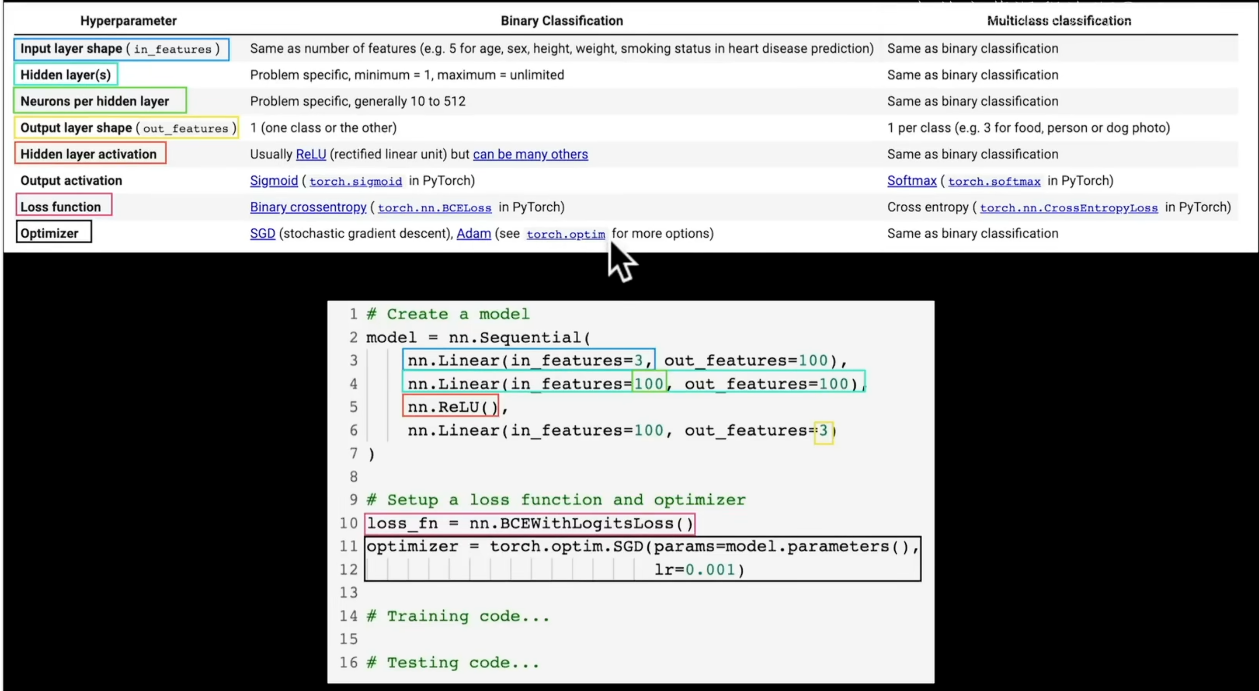

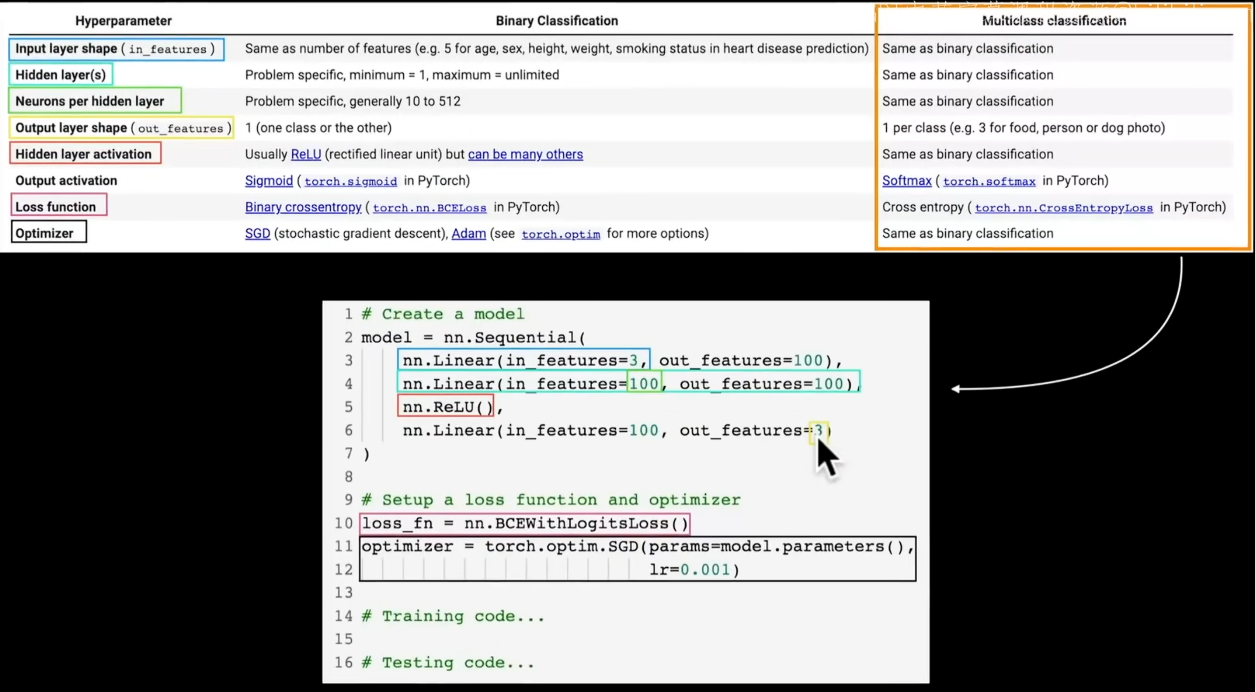

Topo and steps:
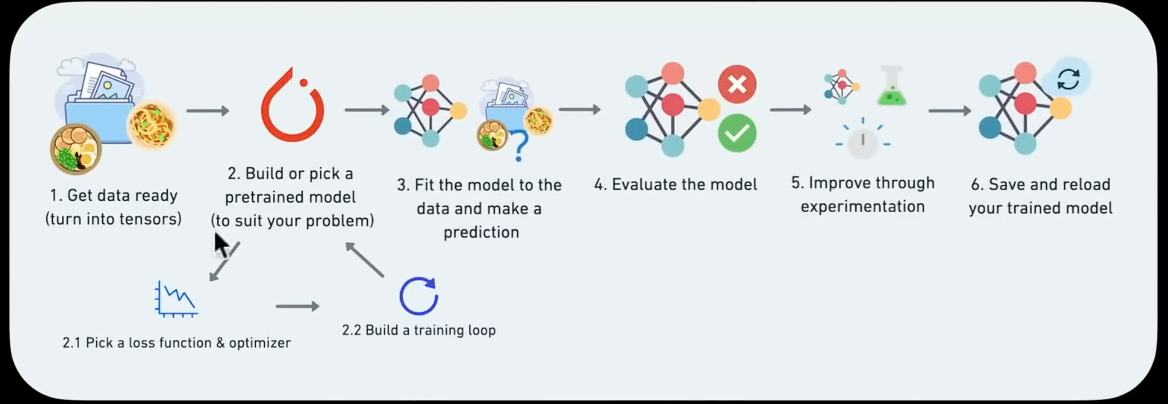

**1. Make classification data and get it ready**

We'll use the make_circles() method from Scikit-Learn to generate two circles with different coloured dots.

In [3]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
            noise=0.03, # a little bit of noise to the dots
            random_state=42) # keep random state so we get the same values

In [4]:
print(f"First 5 X features:\n {X[:5]}")
print(f"\nFirst 5 y labels:\n {y[:5]}")

First 5 X features:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
 [1 1 1 1 0]


two X, one y

make them visualize.

put them into a pandas DataFrame.

In [5]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],
            "X2":X[:,1],
            "label":y
            })
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [6]:
circles.label.value_counts()

,count
label,
1,500
0,500


This is **binary classification** since there's only two options(0 or 1).

How many values of each class are there?

In [7]:
# Check different lables
circles.label.value_counts()

,count
label,
1,500
0,500


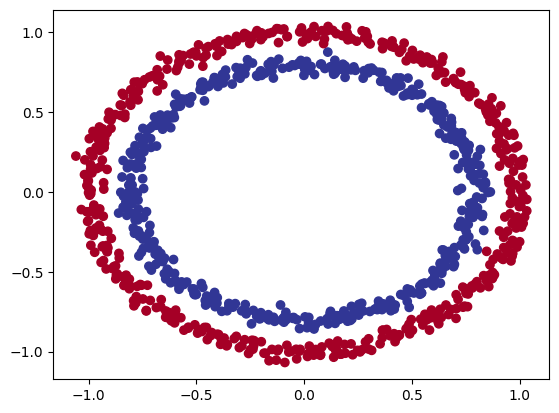

In [8]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
      y=X[:,1],
      c=y,
      cmap=plt.cm.RdYlBu);

Let's find out how we could build a PyTorch neural network to classify dots into red(0) or blue(1).

**Note: **This dataset is often what's considered a **toy problem** (a problem that's used to try and test things out on) in machine learning.

But it represents the major key of classification, you have some kind of data represented as numerical values and you'd like to build a model that's able to classify it, in our case, separate it into red or blue dots.

1.1 Check input and output shapes

In [9]:
# Check the shapes of our features and lables
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [11]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Vaules of one sample of X: {X_sample} and the sample for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the smae for y: {y_sample.shape}")

Vaules of one sample of X: [0.75424625 0.23148074] and the sample for y: 1
Shapes for one sample of X: (2,) and the smae for y: ()


1.2 Turn data into tensors and create train and test splits

In [12]:
import torch
torch.__version__

'2.11.0+cpu'

In [13]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [14]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [15]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [16]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                            y,
                            test_size=0.2, # 20% test, 80% training
                            random_state=42)

In [17]:
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

**2. Building a model**

Let's build a model to classify our blue and red dots.

To do so, we want to:

1. Setup device agonistic code so our code will run on GPU(if there is one).

2. Construct a model (by subclassing nn.Module)

3. Define a loss function and optimizer

4. Create a training and test loop

In [18]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [19]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Let's create a model class that:

Subclasses nn.Module (almost all PyTorch models are subclasses of nn.Module).

Creates 2 nn.Linear layers in the constructor capable of handling the input and output shapes of X and y.

Defines a forward() method containing the forward pass computation of the model.

Instantiates the model class and sends it to the target device.

In [20]:
from sklearn import datasets
# 1. Construct a model that subclassed nn.Module
class CircleModeV0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
      return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output
# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModeV0().to(device)
model_0

CircleModeV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
device

'cpu'

In [22]:
next(model_0.parameters()).device

device(type='cpu')

In [23]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4451, -0.0895],
                      [ 0.2251, -0.1554],
                      [ 0.6099,  0.3974],
                      [-0.5710,  0.0764],
                      [ 0.6996, -0.3681]])),
             ('0.bias', tensor([ 0.1978, -0.5136,  0.4137,  0.0509, -0.6762])),
             ('1.weight',
              tensor([[-0.0873, -0.3265,  0.3966, -0.1289, -0.4157]])),
             ('1.bias', tensor([-0.1415]))])

In [25]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))

print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n {torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 lables:\n {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
 tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.]])

First 10 lables:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


**2.1 Setup loss function and optimizer**

Which loss function or optimizer should you use?

* For example for regression you might want MAE or MSE(mean absolute error or mean squared error).

* For classification you might want binary cross entropy or categorical cross entropy(cross entropy).

* As a reminder, the loss function measures how **wrong** your models predictions are.

* And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

* For some common choices of loss functions and optimizers

* For the loss function we're going to use "torch.nn.BECWithLogitsLoss()".

* BECWithLogitsLoss() 比BECLoss()更稳定，更适用。

For different optimizers see torch.optim.

In [26]:
# Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = requires inputs to have gone through the sigmoid build-in
loss_fn = nn.BCEWithLogitsLoss() # 二元交叉熵 BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
              lr=0.1)

In [27]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4451, -0.0895],
                      [ 0.2251, -0.1554],
                      [ 0.6099,  0.3974],
                      [-0.5710,  0.0764],
                      [ 0.6996, -0.3681]])),
             ('0.bias', tensor([ 0.1978, -0.5136,  0.4137,  0.0509, -0.6762])),
             ('1.weight',
              tensor([[-0.0873, -0.3265,  0.3966, -0.1289, -0.4157]])),
             ('1.bias', tensor([-0.1415]))])

In [28]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

**3. Train model**

Steps:

1. Forward pass

2. Calculate the loss

3. Optimizer zero grad

4. Loss backward(backpropagation)

5. Optimizer step(gradient descent)

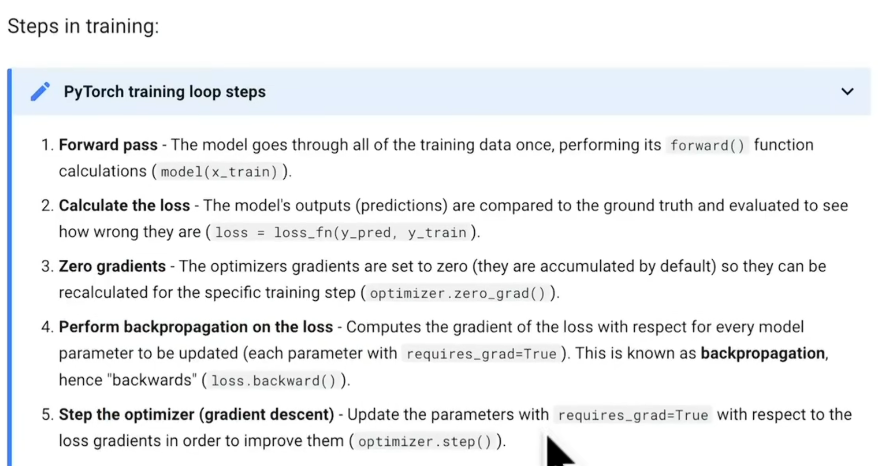

**3.1 Goging from raw logits -> preduction probabilities -> prediction labels**

Our model outputs are going to be **raw logits**. 模型的原始输出

We can converst these **logits** into **prediction probabilities** by passing them to some kind of activation function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can covert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax().

In [29]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[0.7256],
        [0.7910],
        [0.3960],
        [0.8197],
        [0.1449]])

In [30]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [31]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6738],
        [0.6881],
        [0.5977],
        [0.6942],
        [0.5362]])

For our prediction probability values, we need to perform a range-style rounding on them:



*   y_pred_probs >= 0.5, y = 1 (class 1)
*   y_pred_probs < 0.5, y = 0(class 0)



In [32]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred lables )
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.])

In [33]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

**3.2 Building a training and testing**

In [34]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
  # Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

  # 2. Calculate loss/accuracy
  loss = loss_fn(y_logits,
          y_train)
  acc = accuracy_fn(y_true=y_train,
            y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward(backpropagation)
  loss.backward()

  # 5. Optimizer step(gradient descent)
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits,
              y_test)
    test_acc = accuracy_fn(y_true=y_test,
                y_pred=test_pred)

  # Print
  if epoch % 200 == 0:
    print(f"Epoch:{epoch}| Loss:{loss:.5f}, Acc:{acc:.2f}%| Test loss:{test_loss:.5f},Test acc:{test_acc:.2f}%")

Epoch:0| Loss:0.72232, Acc:50.00%| Test loss:0.73008,Test acc:50.00%
Epoch:200| Loss:0.69339, Acc:50.75%| Test loss:0.69752,Test acc:47.50%
Epoch:400| Loss:0.69309, Acc:51.25%| Test loss:0.69609,Test acc:46.50%
Epoch:600| Loss:0.69301, Acc:51.00%| Test loss:0.69544,Test acc:46.50%
Epoch:800| Loss:0.69299, Acc:51.00%| Test loss:0.69510,Test acc:46.00%


**4. Make predictions and evaluate the model**

Form the metrics it looks like our model isn't learning anything..

So to inspect it let's make some predictions and make them visual!

**plot_decision_boundary()**

In [35]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


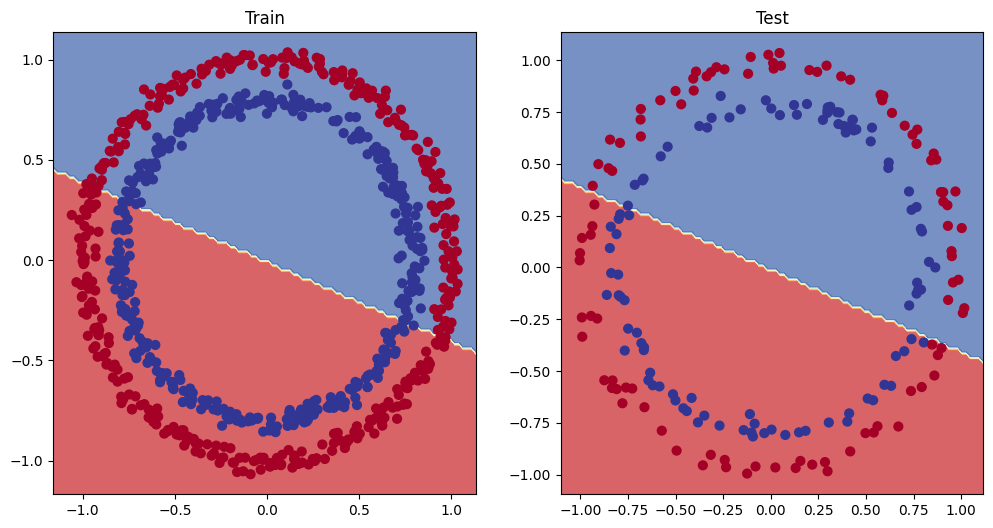

In [36]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

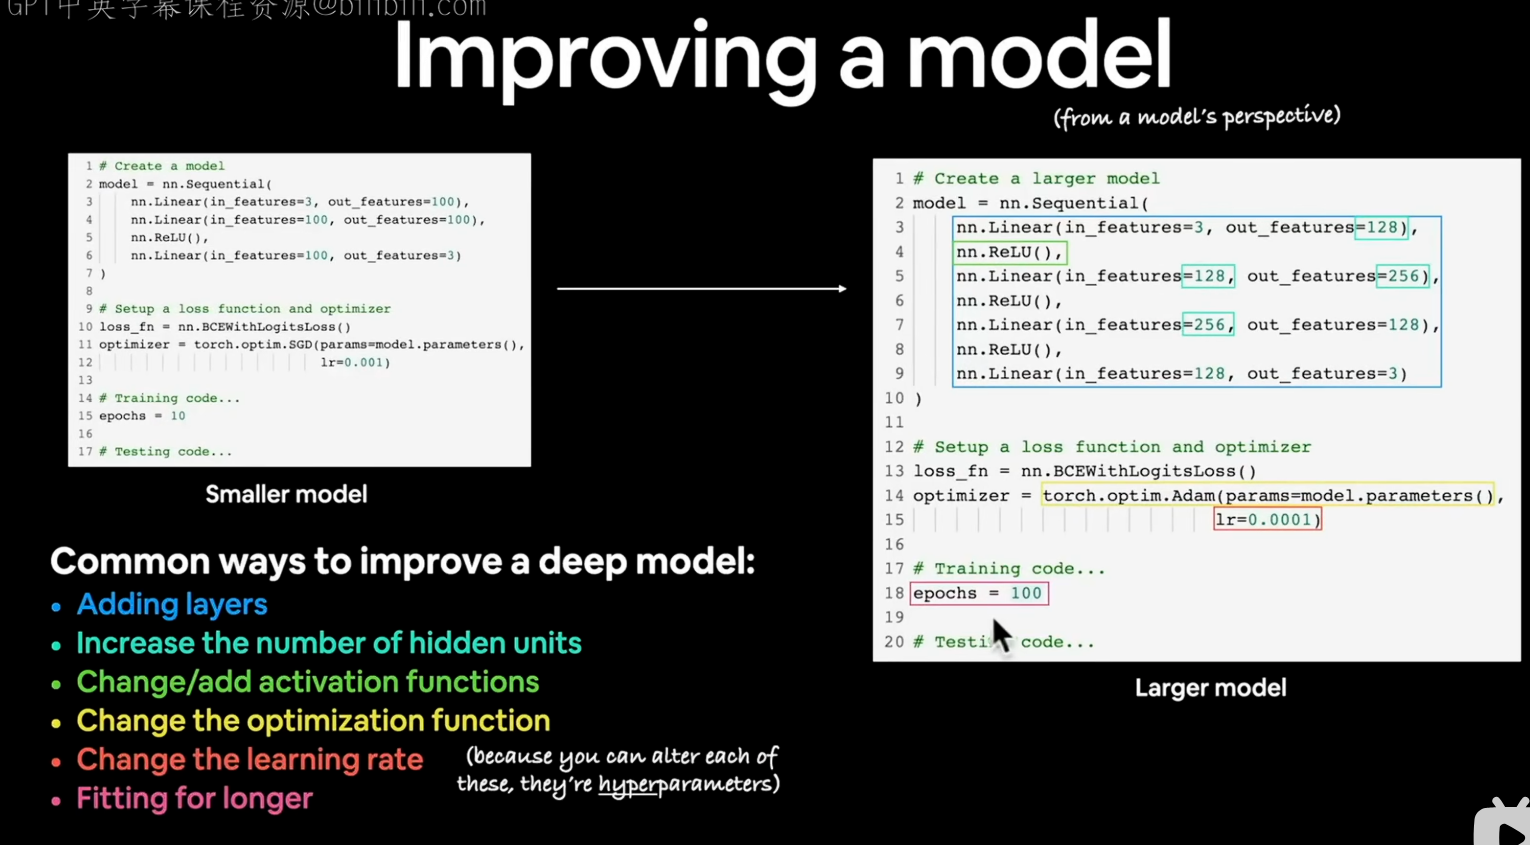

**5. Improving a model (from a model perspective)**

非常重要！！！



*   Add more layers - give the model more chances to learn about patterns in the data
*   Add more hidden units - go from 5 hidden units to 10 hidden units
*   Fit for longer
*   Chaning the activation functions
*   Change the learning rate
*   Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.

And because these options are all values we can change, they are called **hyperparameters**.

Let's try and improve our model by:


*   Adding more hidden units: 5-> 10
*   Increase the number of layers : 2 -> 3
*   Increase the number of epochs: 100 -> 1000



In [37]:
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [38]:
# Create a model
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
              lr=0.1)


In [40]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Taining
  model_1.train()
  # 1. Forwar pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> pred y_pred_labels

  # 2. Calculate loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
            y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step(gradient descent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate loss
    test_loss = loss_fn(test_logits,
              y_test)
    test_acc = accuracy_fn(y_true=y_test,
                y_pred=test_pred)

# Print
  if epoch % 100 == 0:
   print(f"Epoch:{epoch}| Loss:{loss:.5f}, Acc:{acc:.2f}%| Test loss:{test_loss:.5f}%, Test acc:{test_acc:.2f}%")

Epoch:0| Loss:0.69396, Acc:50.88%| Test loss:0.69261%, Test acc:51.00%
Epoch:100| Loss:0.69305, Acc:50.38%| Test loss:0.69379%, Test acc:48.00%
Epoch:200| Loss:0.69299, Acc:51.12%| Test loss:0.69437%, Test acc:46.00%
Epoch:300| Loss:0.69298, Acc:51.62%| Test loss:0.69458%, Test acc:45.00%
Epoch:400| Loss:0.69298, Acc:51.12%| Test loss:0.69465%, Test acc:46.00%
Epoch:500| Loss:0.69298, Acc:51.00%| Test loss:0.69467%, Test acc:46.00%
Epoch:600| Loss:0.69298, Acc:51.00%| Test loss:0.69468%, Test acc:46.00%
Epoch:700| Loss:0.69298, Acc:51.00%| Test loss:0.69468%, Test acc:46.00%
Epoch:800| Loss:0.69298, Acc:51.00%| Test loss:0.69468%, Test acc:46.00%
Epoch:900| Loss:0.69298, Acc:51.00%| Test loss:0.69468%, Test acc:46.00%


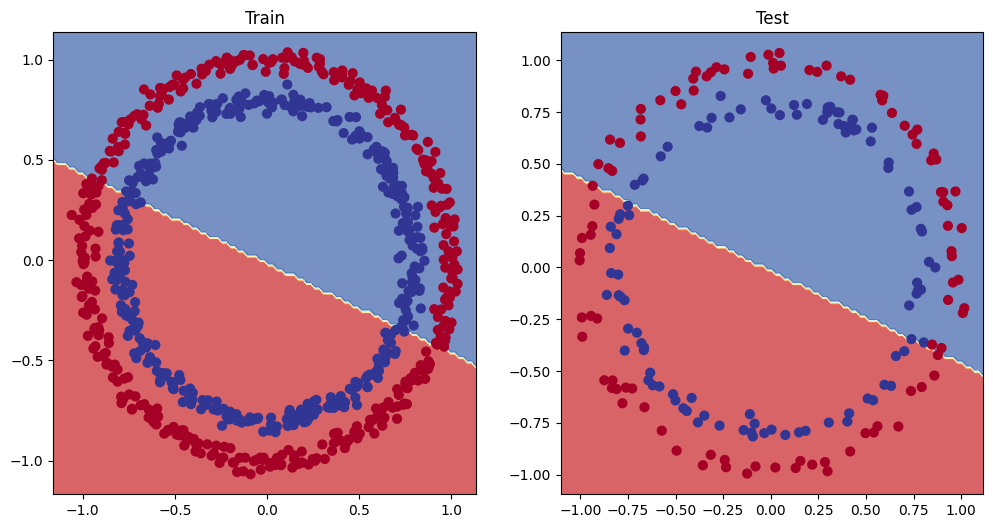

In [41]:
# Plot
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

**5.1 Preparing data to see if our model can fit a straight line**

One way to troubleshoot to a larger problem is to test out a smaller problem.

In [42]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [43]:
# Create train and test splits
#train_split = int(0.8*len(X_regression))
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression),len(y_train_regression),len(X_test_regression),len(y_test_regression))
len(y_test_regression)

80 80 20 20


20

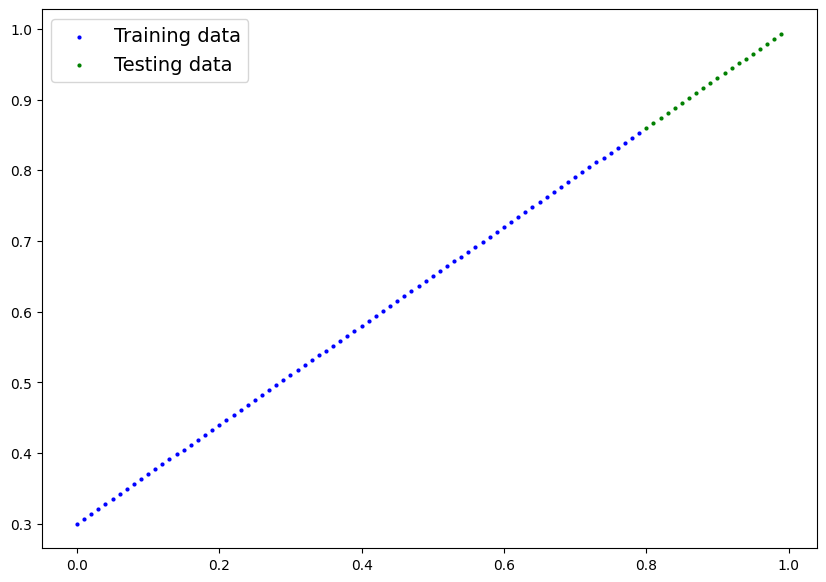

In [44]:
plot_predictions(train_data=X_train_regression,
        train_labels=y_train_regression,
        test_data=X_test_regression,
        test_labels=y_test_regression);

**5.2 Adjusting model_1 to fit a straight line**



In [45]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [46]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(),
              lr=0.01)

In [47]:
# Train the model
torch.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  ## Training
  # 1. Forward pass
  y_pred = model_2(X_train_regression)

  # 2. Calculate loss
  loss = loss_fn(y_pred, y_train_regression)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backwards
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_pred = model_2(X_test_regression)
    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test_regression)

    # Print
    if epoch % 100 == 0:
      print(f"Epoch:{epoch}| Train loss:{loss:.5f}, Test loss:{test_loss:.5f}")

Epoch:0| Train loss:0.75986, Test loss:0.91103
Epoch:100| Train loss:0.02858, Test loss:0.00081
Epoch:200| Train loss:0.02533, Test loss:0.00209
Epoch:300| Train loss:0.02137, Test loss:0.00305
Epoch:400| Train loss:0.01964, Test loss:0.00341
Epoch:500| Train loss:0.01940, Test loss:0.00387
Epoch:600| Train loss:0.01903, Test loss:0.00379
Epoch:700| Train loss:0.01878, Test loss:0.00381
Epoch:800| Train loss:0.01840, Test loss:0.00329
Epoch:900| Train loss:0.01798, Test loss:0.00360


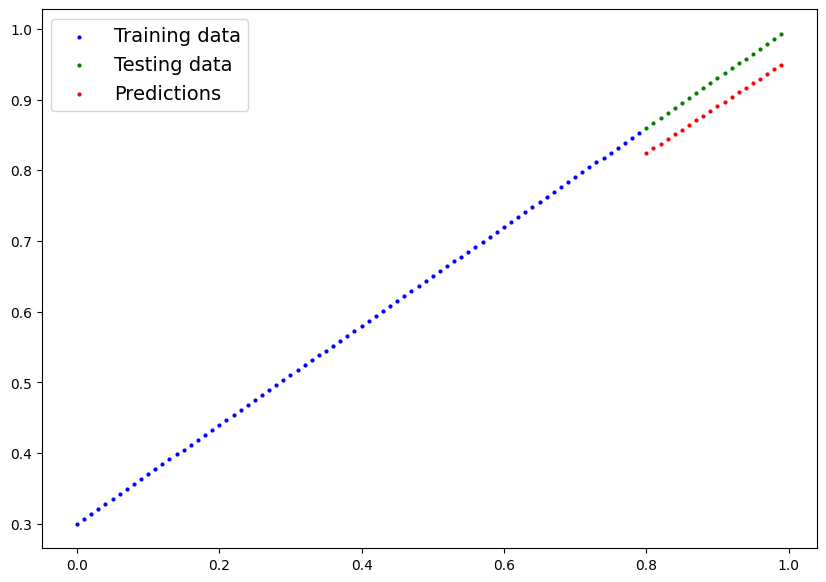

In [48]:
# Turn on evaluation mode
model_2.eval()

# Make predictions(inference)
with torch.inference_mode():
  y_preds = model_2(X_test_regression)
  plot_predictions(train_data=X_train_regression.cpu(),
          train_labels=y_train_regression.cpu(),
          test_data=X_test_regression.cpu(),
          test_labels=y_test_regression.cpu(),
          predictions=y_preds.cpu());

**6. The missing piece: non-linearity**

**6.1 Recreating non-linear data (red and blue circles)**

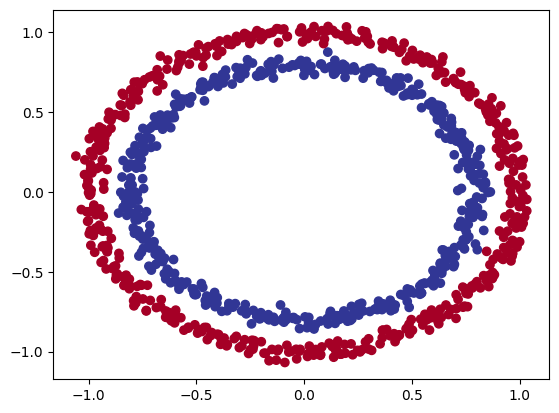

In [50]:
# Make and plot data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
            noise=0.03,
             random_state=42,)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [51]:
# Covert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                            y,
                            test_size=0.2,
                            random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

**6.2 Building a model with non-linearity**



*   Linear = straight lines
*   Non-linear = non-straight lines

Artificial neural networks are a large combination of linear (straight) and non-straight(non-linear) functions which are potentially able to find patterns in data.*italicized text*



In [52]:
# Build a model with non-linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [60]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
              lr=0.01)

**6.3 Traing a model with non-linearity**

In [61]:
len(X_test),len(y_test)

(200, 200)

In [62]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through data
epochs = 1000

for epoch in range(epochs):
  # Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
            y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Calculate loss
    test_loss = loss_fn(test_logits,
              y_test)
    test_acc = accuracy_fn(y_true=y_test,
                y_pred=test_pred)

  # Print
  if epoch % 100 == 0:
    print(f"Epoch:{epoch}| Loss:{loss:.5f}, Acc:{acc:.2f}%| Test loss:{test_loss:.5f}%, Test acc:{test_acc:.2f}%")


Epoch:0| Loss:0.56818, Acc:87.75%| Test loss:0.57434%, Test acc:86.50%
Epoch:100| Loss:0.56076, Acc:88.50%| Test loss:0.56802%, Test acc:88.00%
Epoch:200| Loss:0.55313, Acc:89.25%| Test loss:0.56144%, Test acc:89.00%
Epoch:300| Loss:0.54518, Acc:90.00%| Test loss:0.55461%, Test acc:89.50%
Epoch:400| Loss:0.53695, Acc:90.75%| Test loss:0.54752%, Test acc:89.50%
Epoch:500| Loss:0.52845, Acc:91.38%| Test loss:0.54013%, Test acc:89.50%
Epoch:600| Loss:0.51967, Acc:92.38%| Test loss:0.53258%, Test acc:89.50%
Epoch:700| Loss:0.51053, Acc:92.75%| Test loss:0.52476%, Test acc:90.00%
Epoch:800| Loss:0.50106, Acc:93.12%| Test loss:0.51655%, Test acc:90.00%
Epoch:900| Loss:0.49138, Acc:93.50%| Test loss:0.50832%, Test acc:89.50%


**6.4 Evaluating a model trained with non-linear activation functions**



In [63]:
# Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]


(tensor([1., 1., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

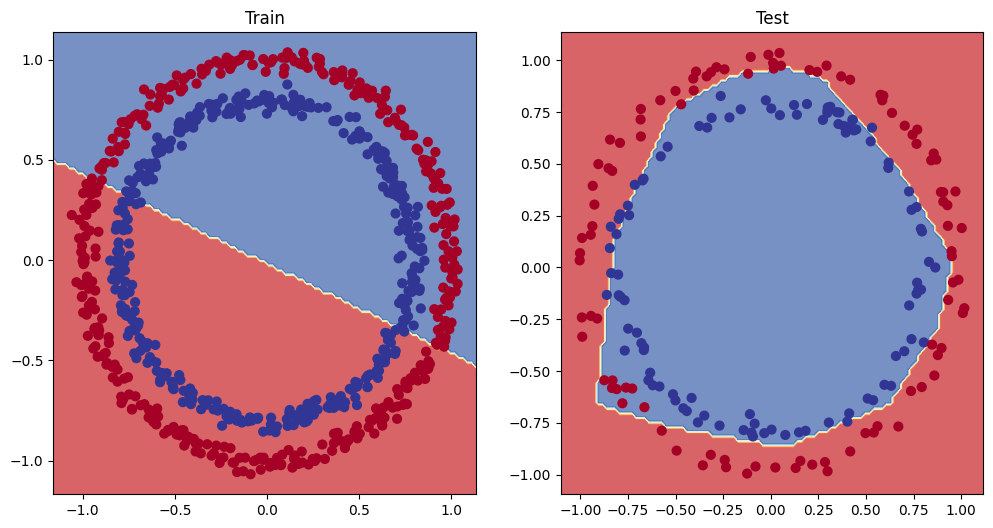

In [64]:
# Plot
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train) # model_1 = no non-linearity
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test); # model_3 = has non-linearity

7. Replicating non-linear activation functions

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear & non-linear functions.

In [65]:
# Create a toy tensor
A = torch.arange(-10,10,1,dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

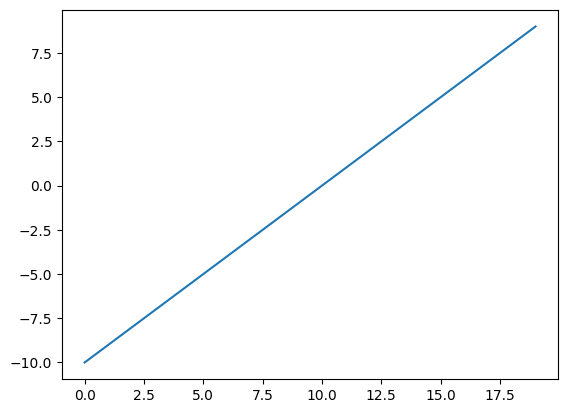

In [66]:
plt.plot(A)

In [74]:
# Create ReLU function by hand
def relu(x):
  return torch.maximum(torch.tensor(0),x)
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

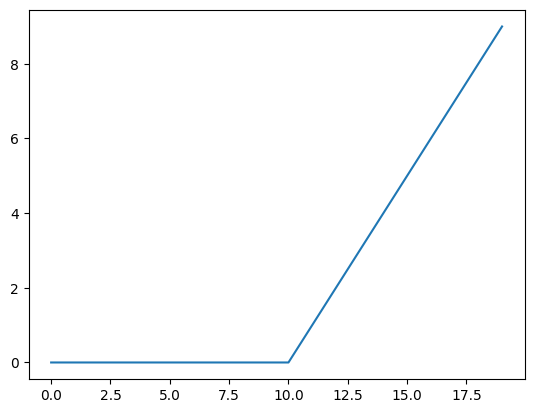

In [75]:
plt.plot(relu(A))

In [77]:
# Create a custom sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

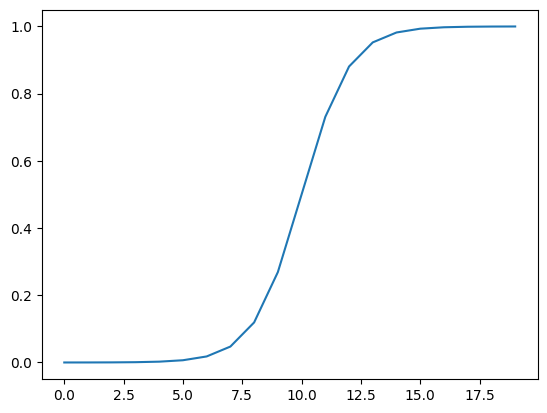

In [78]:
plt.plot(sigmoid(A))

8.